In [13]:
# ==============================================
# 01_baseline_text_classification_final.ipynb
# Phase 1 – Machine Learning for Vishing Detection (FYP)
# ==============================================

import re
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt


from sklearn.model_selection import GroupShuffleSplit
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, balanced_accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

import joblib

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, Model

print("✅ Imports loaded.")


✅ Imports loaded.


In [14]:
# === 2) LOAD DATASET ===
BASE_DIR = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
data_path = BASE_DIR / "data" / "english_dataset_final_v2.csv"

df = pd.read_csv(data_path)
df["transcript"] = df["transcript"].astype(str)
df["label"] = df["label"].astype(str).str.lower().str.strip()

print(f"✅ Loaded: {data_path}")
print("Rows:", len(df))
print("Label counts:\n", df["label"].value_counts())

# === 3) KOREAN-FRIENDLY NORMALIZATION ===
# Keep Hangul. Only normalize whitespace + remove invisible junk.
def normalize_text(s: str) -> str:
    s = str(s)
    s = s.replace("\u200b", " ")          # zero-width space
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["clean_text"] = df["transcript"].apply(normalize_text)

# === 4) CHECK DUPLICATES (this often explains 1.00 scores) ===
dup_count = df["clean_text"].duplicated().sum()
print("Duplicate transcripts:", dup_count)

# Optional: drop exact duplicates (recommended)
df = df.drop_duplicates(subset=["clean_text", "label"]).reset_index(drop=True)
print("After dropping exact duplicates:", len(df))
print("Label counts after drop:\n", df["label"].value_counts())

# === 5) LEAKAGE-SAFE SPLIT using groups (identical texts stay in same split) ===
# Group by transcript content so same text cannot be in both train and test
groups = pd.factorize(df["clean_text"])[0]

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(gss.split(df["clean_text"], df["label"], groups=groups))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

X_train = train_df["clean_text"].values
y_train = train_df["label"].values
X_test  = test_df["clean_text"].values
y_test  = test_df["label"].values

print("\n✅ Split done (leakage-safe).")
print("Train:", Counter(y_train))
print("Test :", Counter(y_test))

# Sanity check: no identical texts across splits
overlap = set(train_df["clean_text"]).intersection(set(test_df["clean_text"]))
print("Identical transcript overlap across splits:", len(overlap))


✅ Loaded: d:\FYP1\VishingDetection\data\english_dataset_final_v2.csv
Rows: 1803
Label counts:
 label
vishing    1266
safe        537
Name: count, dtype: int64
Duplicate transcripts: 0
After dropping exact duplicates: 1803
Label counts after drop:
 label
vishing    1266
safe        537
Name: count, dtype: int64

✅ Split done (leakage-safe).
Train: Counter({'vishing': 877, 'safe': 385})
Test : Counter({'vishing': 389, 'safe': 152})
Identical transcript overlap across splits: 0


In [15]:
# === 6) FEATURE EXTRACTOR (Korean-friendly char n-grams) ===
tfidf_char = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3, 5),
    min_df=2,
    max_df=0.95,
    max_features=30000
)

# === 7) MODELS ===
lr = Pipeline([
    ("tfidf", tfidf_char),
    ("clf", LogisticRegression(max_iter=3000, class_weight="balanced"))
])

rf = Pipeline([
    ("tfidf", tfidf_char),
    ("clf", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

# For confidence, calibrate SVM (gives predict_proba)
svm_base = Pipeline([
    ("tfidf", tfidf_char),
    ("clf", LinearSVC(class_weight="balanced", random_state=42))
])
svm = CalibratedClassifierCV(svm_base, method="sigmoid", cv=3)

models = {
    "SVM (Calibrated)": svm,
    "Logistic Regression": lr,
    "Random Forest": rf
}

results = {}

print("\n=== BASELINE RESULTS (Leakage-safe split) ===")
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    bacc = balanced_accuracy_score(y_test, pred)
    f1m = f1_score(y_test, pred, average="macro")

    print(f"\n--- {name} ---")
    print(classification_report(y_test, pred, digits=3))
    print("Accuracy:", round(acc, 4),
          "| Balanced Acc:", round(bacc, 4),
          "| F1-macro:", round(f1m, 4))

    results[name] = {"acc": acc, "bacc": bacc, "f1_macro": f1m}

print("\n✅ Baseline training complete.")



=== BASELINE RESULTS (Leakage-safe split) ===

--- SVM (Calibrated) ---
              precision    recall  f1-score   support

        safe      0.955     0.980     0.968       152
     vishing      0.992     0.982     0.987       389

    accuracy                          0.982       541
   macro avg      0.974     0.981     0.977       541
weighted avg      0.982     0.982     0.982       541

Accuracy: 0.9815 | Balanced Acc: 0.9811 | F1-macro: 0.9773

--- Logistic Regression ---
              precision    recall  f1-score   support

        safe      0.908     0.974     0.940       152
     vishing      0.989     0.961     0.975       389

    accuracy                          0.965       541
   macro avg      0.949     0.968     0.957       541
weighted avg      0.967     0.965     0.965       541

Accuracy: 0.9649 | Balanced Acc: 0.9676 | F1-macro: 0.9575

--- Random Forest ---
              precision    recall  f1-score   support

        safe      0.948     0.967     0.958     

✅ Best baseline by F1-macro: SVM (Calibrated)


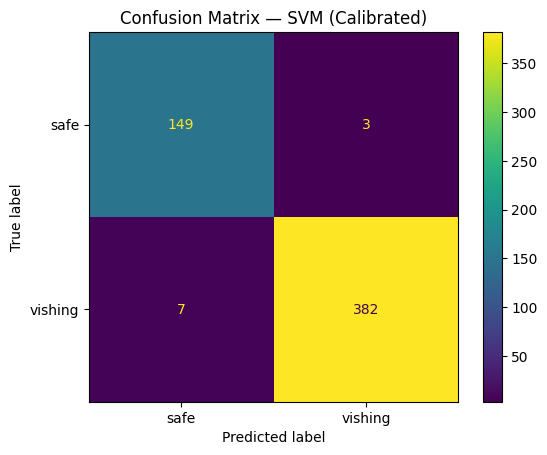

Predicted label distribution: Counter({'vishing': 385, 'safe': 156})


In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

best_name = max(results, key=lambda k: results[k]["f1_macro"])
best_model = models[best_name]

print("✅ Best baseline by F1-macro:", best_name)

pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, pred_best, labels=["safe", "vishing"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["safe", "vishing"])
disp.plot()
plt.title(f"Confusion Matrix — {best_name}")
plt.show()

# How often does it predict each class?
print("Predicted label distribution:", Counter(pred_best))


In [17]:
# === 8) KERAS MODEL (no TF-IDF toarray, so no MemoryError) ===
# Binary target: vishing=1, safe=0
y_train_bin = (y_train == "vishing").astype(np.int32)
y_test_bin  = (y_test == "vishing").astype(np.int32)

# Text vectorizer (character-level)
max_tokens = 2000
seq_len = 300

text_vec = layers.TextVectorization(
    standardize=None,
    split="character",
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=seq_len
)
text_vec.adapt(X_train)

inputs = layers.Input(shape=(1,), dtype=tf.string)
x = text_vec(inputs)

x = layers.Embedding(input_dim=max_tokens, output_dim=64)(x)
x = layers.Conv1D(128, 5, activation="relu")(x)
x = layers.GlobalMaxPooling1D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

nn_model = Model(inputs, outputs)
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Class weights to reduce imbalance bias
count_safe = np.sum(y_train_bin == 0)
count_vish = np.sum(y_train_bin == 1)
total = len(y_train_bin)
class_weight = {
    0: total / (2 * count_safe),
    1: total / (2 * count_vish)
}
print("Class_weight:", class_weight)

history = nn_model.fit(
    X_train, y_train_bin,
    validation_data=(X_test, y_test_bin),
    epochs=6,
    batch_size=32,
    class_weight=class_weight,
    verbose=1
)

# Evaluate NN properly
nn_probs = nn_model.predict(X_test, verbose=0).reshape(-1)
nn_pred = (nn_probs >= 0.5).astype(int)

nn_acc = accuracy_score(y_test_bin, nn_pred)
nn_bacc = balanced_accuracy_score(y_test_bin, nn_pred)
nn_f1m = f1_score(y_test_bin, nn_pred, average="macro")

print("\n=== NEURAL NET RESULTS ===")
print("Accuracy:", round(nn_acc, 4),
      "| Balanced Acc:", round(nn_bacc, 4),
      "| F1-macro:", round(nn_f1m, 4))


Class_weight: {0: np.float64(1.638961038961039), 1: np.float64(0.7194982896237172)}
Epoch 1/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - accuracy: 0.6846 - loss: 0.6401 - val_accuracy: 0.8669 - val_loss: 0.4918
Epoch 2/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.8542 - loss: 0.3731 - val_accuracy: 0.9039 - val_loss: 0.2503
Epoch 3/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9334 - loss: 0.1703 - val_accuracy: 0.9409 - val_loss: 0.1400
Epoch 4/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.9651 - loss: 0.0977 - val_accuracy: 0.9649 - val_loss: 0.0902
Epoch 5/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9707 - loss: 0.0717 - val_accuracy: 0.9575 - val_loss: 0.0990
Epoch 6/6
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.9826 - loss: 0.0522 - val_accuracy: 0.9797 - val_loss: 0.0724

=== NEURAL NET RESULTS ===
Accuracy: 0.9797 | Balanced Acc: 0.9819 | F1-macro: 0.9752


In [18]:
# 9) SAVE MODELS FOR PROTOTYPE 
save_dir = BASE_DIR / "models"
save_dir.mkdir(exist_ok=True)

joblib.dump(models["SVM (Calibrated)"], save_dir / "svm_model.pkl")
joblib.dump(models["Logistic Regression"], save_dir / "logistic_regression_model.pkl")
joblib.dump(models["Random Forest"], save_dir / "rf_model.pkl")

nn_model.save(save_dir / "neural_network.keras")

print(" Saved:")
print("-", (save_dir / "svm_model.pkl").resolve())
print("-", (save_dir / "logistic_regression_model.pkl").resolve())
print("-", (save_dir / "rf_model.pkl").resolve())
print("-", (save_dir / "neural_network.keras").resolve())


UnicodeEncodeError: 'charmap' codec can't encode character '\u0441' in position 264: character maps to <undefined>

In [ ]:
# === 10) PROTOTYPE SYNC TEST ===
from tensorflow.keras.models import load_model

svm_loaded = joblib.load(save_dir / "svm_model.pkl")
lr_loaded  = joblib.load(save_dir / "logistic_regression_model.pkl")
rf_loaded  = joblib.load(save_dir / "rf_model.pkl")
nn_loaded  = load_model(save_dir / "neural_network.keras")

samples = [
    "안녕하세요. 내일 회의 일정이 변경되었습니다. 감사합니다.",  # likely safe
    "검찰청입니다. 귀하의 계좌가 범죄에 연루되었습니다. 즉시 확인해야 합니다.",  # likely vishing
]

print("SVM:", svm_loaded.predict(samples))
print("LR :", lr_loaded.predict(samples))
print("RF :", rf_loaded.predict(samples))

nn_p = nn_loaded.predict(np.array(samples), verbose=0).reshape(-1)
nn_lab = np.where(nn_p >= 0.5, "vishing", "safe")
print("NN :", nn_lab, "| probs:", np.round(nn_p, 3))
